### Tutorial: An overview of 3D Vision-Language Models

[Project page](https://usmarcv.github.io/Tutorial-3DVLMs/) | [Paper](https://arxiv.org/abs/2609.05583)

---


# Hands-on: Contrastive Learning for 3D Vision-Language Models

This notebook turns the pipeline of a 3D Vision-Language contrastive-learning
system into runnable code, using a small subset of real ShapeNet objects from
our own training data.

## Why align 3D to a *frozen* CLIP?

Paired 3D-text data is scarce - a few hundred thousand objects, versus billions of
image-text pairs used to train CLIP. Instead of learning language from scratch, 3D
vision-language models such as **ULIP**, **OpenShape** and **Uni3D** keep a strong,
pretrained image-text model **frozen** and train only a 3D encoder to land in *its*
embedding space. The 3D encoder then inherits CLIP's semantics for free: once a
point cloud lives in the same space as text and images, it can be compared against
*any* sentence or photo - that is what enables zero-shot classification and
cross-modal retrieval later on.

## The pipeline we're about to build

```
ShapeNet sample --> Point Cloud / Image / Text --> Feature Encoders --> Normalize
       --> Joint Embedding Space --> Similarity Matrix --> Contrastive Loss
       --> Backpropagation (updates ONLY the 3D encoder)
```

A batch of `(3D, image, text)` triplets goes through **feature extraction**,
then **normalize and compare**, then a **symmetric objective** (computed in
both directions), and backprop updates only the trainable 3D encoder
$E_\theta^S$ - everything else is frozen.

## The three modalities

- **3D** - a colored point cloud $P$ sampled from a ShapeNet mesh.
- **Image** - a rendered view $I$ of the same object.
- **Text** - a short description / class label $T$ of the same object.

Each triplet $(P_i, I_i, T_i)$ describes the *same* physical object from three
completely different representations. The goal of contrastive learning is to
teach a 3D encoder to map $P$ into a point in the same semantic space that an
already-trained vision-language model (OpenCLIP) uses for $I$ and $T$.

## Two simplifications, stated up front

1. **No live OpenCLIP calls.** Image and text embeddings for every object were
   already computed offline with **OpenCLIP ViT-bigG-14 (laion2b_s39b_b160k)** and
   are stored on disk. This notebook never loads OpenCLIP itself - it only *reads*
   those frozen vectors, exactly like the full-scale trainer in the original
   3DMRL research code (not included in this repository) does. Only the equations
   $z_{img}=f_{img}(I)$ and $z_{txt}=f_{txt}(T)$ are shown conceptually; the arrows
   themselves were run once, offline, when the dataset was built.
2. **No raw rendered pixels.** This repository only ships the *point clouds* and the
   *precomputed CLIP image embeddings* for these ShapeNet objects - not the actual
   rendered photos. Wherever we want to *look at* the "Image" modality, we instead
   draw a quick point-cloud snapshot and label it clearly as a **pseudo-render
   proxy** - it is not a real photo. The math never uses this proxy; `z_img`
   everywhere below is the real, precomputed CLIP image embedding.

Only $z_{3D} = f_{3D}(P)$ is actually computed live in this notebook, using
**Point-BERT** (arXiv:2111.14819) - because that's the one component we're
training.


## 1. Setup

Run the cell below once per environment. Everything this notebook uses beyond the
Python standard library and PyTorch is installed by it - the rest of the tutorial
(including the vendored Point-BERT/LogitScaleNetwork code in `handson_utils/`)
never needs anything outside this repository.

`torch` itself is assumed to already be installed, matching your machine's CPU/GPU
setup (install command varies by CUDA version - see
[pytorch.org/get-started](https://pytorch.org/get-started/locally/) if you need it).


In [1]:
# One-time environment setup. Safe to re-run (pip skips anything already installed).
!pip install -q torch_redstone einops plotly ipywidgets scikit-learn matplotlib nbformat


In [2]:
import os, sys, json, time, random

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from sklearn.decomposition import PCA

sys.path.insert(0, os.path.abspath("."))
from handson_utils import data_loading, model_setup, viz

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
DEVICE = "cpu" 

torch: 2.14.0+cu130 | CUDA available: True


## 2. Exploring ShapeNet

We work with a fixed, cached subset of **110 ShapeNet objects across 54 categories**
(2 objects per category, 4 for one of them), drawn from the ~52k-object ShapeNet
training split of the original 3DMRL research code. The subset is cached to
`subset_manifest.json` and its raw data to `dataset/`, so this repository is fully
self-contained and re-running the notebook during a live talk is fast.


In [4]:
MANIFEST_PATH = "subset_manifest.json"
manifest = data_loading.load_manifest(MANIFEST_PATH)

categories = sorted(set(r["category"] for r in manifest))
print(f"{len(manifest)} objects across {len(categories)} categories")
print("first few categories:", categories[:10])


110 objects across 54 categories
first few categories: ['airplane', 'ashcan', 'bag', 'basket', 'bathtub', 'bed', 'bench', 'birdhouse', 'bookshelf', 'bottle']


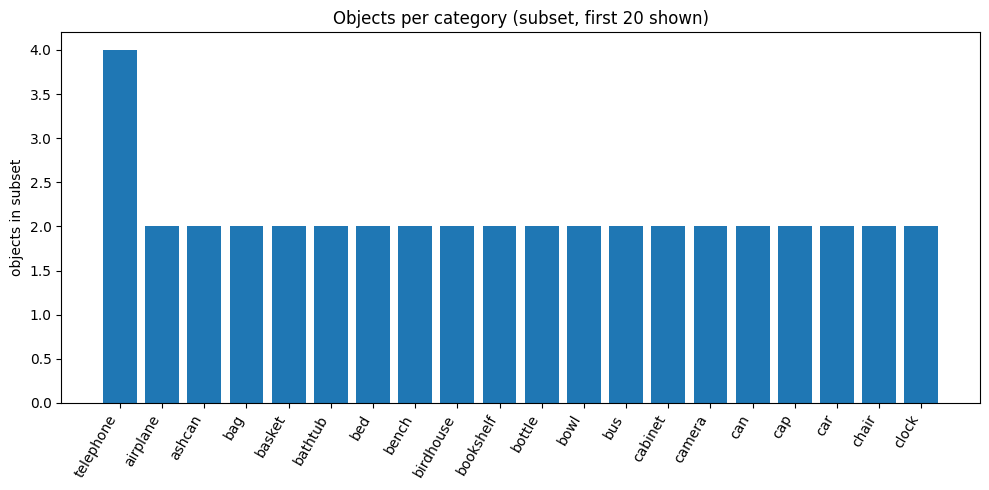

In [4]:
from collections import Counter

counts = Counter(r["category"] for r in manifest)
top = counts.most_common(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([c for c, _ in top], [n for _, n in top])
ax.set_ylabel("objects in subset")
ax.set_title("Objects per category (subset, first 20 shown)")
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
plt.tight_layout()
plt.show()


## 3. Interactive Point Cloud Visualization

Pick any object below and inspect its **raw input to the 3D encoder**: a colored
point cloud $P \in \mathbb{R}^{N \times 6}$ (xyz + rgb). Rotate, zoom, and look
at the object exactly as `f_3D` will see it. The caption underneath is that
object's text description $T$.


In [5]:
# Note: we redraw a fresh Plotly figure per selection (via ipywidgets.Output)
# rather than mutating a go.FigureWidget in place - this avoids an extra
# `anywidget` dependency and keeps the widget portable across Jupyter frontends,
# which matters more than update smoothness for a live-talk demo.
by_category = {}
for r in manifest:
    by_category.setdefault(r["category"], []).append(r)

category_dd = widgets.Dropdown(options=sorted(by_category.keys()), description="Category:")
uid_dd = widgets.Dropdown(options=[r["uid"] for r in by_category[category_dd.value]], description="Object:")
out = widgets.Output()


def _find_record(category, uid):
    return next(r for r in by_category[category] if r["uid"] == uid)


def _update(*_):
    record = _find_record(category_dd.value, uid_dd.value)
    obj = data_loading.load_object(record, num_points=10000)
    fig = viz.plot_pointcloud_3d(obj["xyz"], obj["rgb"], title=f"{obj['category']}  ({obj['uid'][:8]}...)")
    with out:
        out.clear_output(wait=True)
        fig.show()
        print("Text description (T):", obj["caption"])


def _on_category_change(change):
    if change["name"] == "value":
        uid_dd.options = [r["uid"] for r in by_category[category_dd.value]]
        _update()


category_dd.observe(_on_category_change, names="value")
uid_dd.observe(_update, names="value")

display(widgets.VBox([widgets.HBox([category_dd, uid_dd]), out]))
_update()


## 4. Three Modalities: Point Cloud <-> Image <-> Text

Let's freeze on one running example - **"a chair"**. Below, all three
representations describe the *same* semantic object:


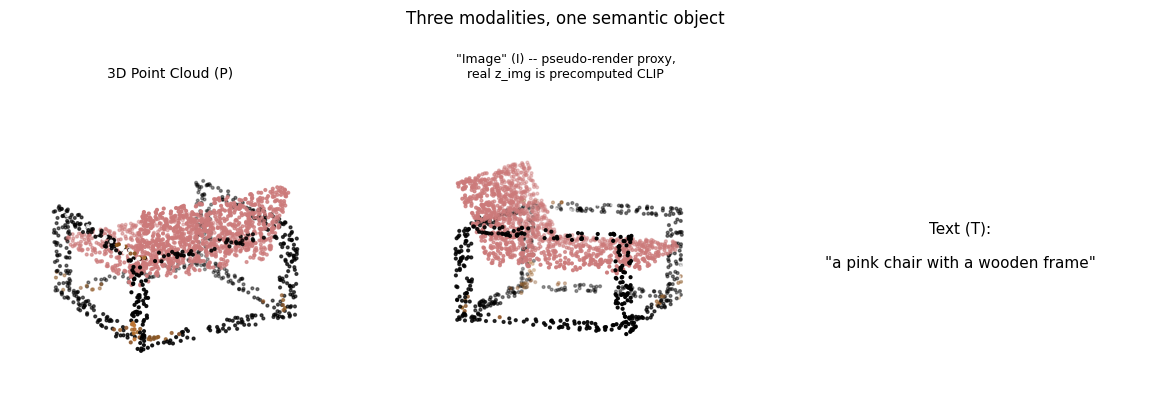

In [6]:
chair_record = next(r for r in manifest if r["category"] == "chair")
chair_obj = data_loading.load_object(chair_record, num_points=2048, seed=0)

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
viz.pointcloud_pseudo_render(ax1, chair_obj["xyz"], chair_obj["rgb"])
ax1.set_title("3D Point Cloud (P)", fontsize=10)

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
viz.pointcloud_pseudo_render(ax2, chair_obj["xyz"], chair_obj["rgb"], elev=10, azim=200)
ax2.set_title("\"Image\" (I) -- pseudo-render proxy,\nreal z_img is precomputed CLIP", fontsize=9)

ax3 = fig.add_subplot(1, 3, 3)
ax3.axis("off")
ax3.text(0.5, 0.5, f'Text (T):\n\n\"{chair_obj["caption"]}\"',
          ha="center", va="center", wrap=True, fontsize=11)

plt.suptitle("Three modalities, one semantic object", y=1.03)
plt.tight_layout()
plt.show()


## 5. Feature Extraction

$$z_{3D} = f_{3D}(P) \qquad z_{img} = f_{img}(I) \qquad z_{txt} = f_{txt}(T)$$

| Encoder | Backbone | Status |
|---|---|---|
| $f_{img}$ | OpenCLIP ViT-bigG-14 (laion2b_s39b_b160k) | **Frozen** - never runs in this notebook, embeddings read from disk |
| $f_{txt}$ | OpenCLIP ViT-bigG-14 (laion2b_s39b_b160k) | **Frozen** - same as above |
| $f_{3D}$  | Point-BERT (arXiv:2111.14819), scaling=1 preset | **Trainable** - this is what we'll actually run and later train |

**What $f_{3D}$ (Point-BERT) does, in one breath:**

1. **Patchify** - farthest-point sampling picks 64 patch centers; each center groups
   up to 256 neighbors within a radius (a "ball query").
2. **Tokenize** - a small PointNet turns each patch (its points' xyz + rgb, i.e. the
   6-channel `features` input) into one token vector.
3. **Transformer** - a learnable `[CLS]` token is prepended and 6 transformer layers
   let all patches attend to each other (with a positional bias from the patch
   centers' relative positions).
4. **Project** - the final `[CLS]` token is linearly projected to **1280 dims**, which
   is *exactly* the embedding width of OpenCLIP ViT-bigG-14. Matching widths is what
   makes a dot product between $z_{3D}$ and $z_{img}$ / $z_{txt}$ possible at all.

We build the 3D encoder now. It has no pretrained checkpoint at this size -
it starts **randomly initialized**, so right now its output direction is
essentially meaningless. That's the point: Section 11 will show what changes
after a few steps of contrastive training.


In [7]:
model = model_setup.build_pointbert(scaling=1, in_channel=6, out_channel=1280)
logit_scale_net = model_setup.build_logit_scale()
n_params = sum(p.numel() for p in model.parameters())
print(f"Point-BERT (scaling=1): {n_params:,} parameters, randomly initialized")

model.eval()
with torch.no_grad():
    xyz = torch.from_numpy(chair_obj["xyz"]).unsqueeze(0)
    feats = torch.from_numpy(chair_obj["features"]).unsqueeze(0)
    z_3d_raw = model(xyz, feats)[0]

z_img_raw = torch.from_numpy(chair_obj["img_feat"])   # already read from disk, precomputed
z_txt_raw = torch.from_numpy(chair_obj["text_feat"])  # already read from disk, precomputed

print("z_3D  raw:", z_3d_raw.shape, " norm =", z_3d_raw.norm().item())
print("z_img raw:", z_img_raw.shape, "norm =", z_img_raw.norm().item())
print("z_txt raw:", z_txt_raw.shape, "norm =", z_txt_raw.norm().item())


Point-BERT (scaling=1): 5,100,768 parameters, randomly initialized
z_3D  raw: torch.Size([1280])  norm = 28.9066162109375
z_img raw: torch.Size([1280]) norm = 1.0
z_txt raw: torch.Size([1280]) norm = 0.9999999403953552


**What to observe.** The CLIP embeddings come off disk already unit-length (norm $\approx 1$),
while the untrained Point-BERT output has an arbitrary norm (tens). If we compared raw vectors,
that magnitude would dominate every dot product - which is why the next step normalizes.

## 6. Feature Normalization

$$\hat{z} = \frac{z}{\lVert z \rVert_2}$$

**Normalization removes magnitude. Each embedding becomes a direction.** Once
every embedding has length 1, all of them lie on the same unit
hypersphere, and their dot product is exactly the **cosine similarity** between
their directions - which is all contrastive learning ever compares.


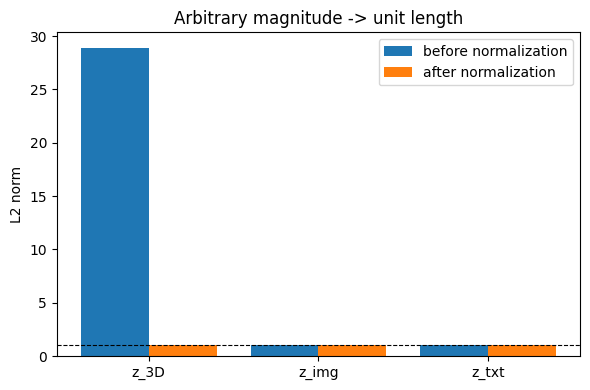

In [8]:
z_3d_hat = F.normalize(z_3d_raw, dim=0)
z_img_hat = F.normalize(z_img_raw, dim=0)
z_txt_hat = F.normalize(z_txt_raw, dim=0)

names = ["z_3D", "z_img", "z_txt"]
before = [z_3d_raw.norm().item(), z_img_raw.norm().item(), z_txt_raw.norm().item()]
after = [z_3d_hat.norm().item(), z_img_hat.norm().item(), z_txt_hat.norm().item()]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - 0.2, before, width=0.4, label="before normalization")
ax.bar(x + 0.2, after, width=0.4, label="after normalization")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("L2 norm")
ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.legend()
ax.set_title("Arbitrary magnitude -> unit length")
plt.tight_layout()
plt.show()


## 7. Joint Embedding Space

**Frozen image and text embeddings define the semantic reference space. The 3D
encoder learns to align its representation through relative similarities with
matched and non-matched samples.**

Below we take ~18 objects, compute $\hat{z}_{3D}$, $\hat{z}_{img}$, $\hat{z}_{txt}$
for each, and project **all of them together** through one shared PCA basis (so all
three modalities land in the same 3 axes - this is literally the "joint embedding
space"). We highlight our chair as the **anchor**, its own image embedding as the
**positive**, and an unrelated object's image embedding as the **negative**.

**Two things to keep in mind when reading this plot:**

- **PCA squeezes 1280 dims into 3.** It keeps the directions of largest variance, not
  the distances we care about, so treat it as a qualitative picture - the similarity
  matrices in Section 8 are the quantitative truth.
- **Expect image and text to form separate clouds.** Even in a perfectly trained CLIP,
  image embeddings and text embeddings occupy different regions of the sphere (the
  well-known *modality gap*). Matching pairs are closer to each other *relative to
  non-matching ones*, not literally on top of each other. The 3D points will likewise
  end up as a third cloud - what matters is relative ranking, which is exactly what
  the contrastive loss optimizes.

Because Point-BERT is still untrained, expect the 3D points to look scattered and
*not* obviously closer to their matching image/text points yet - Section 11 revisits
this exact plot after training.


In [9]:
JOINT_SUBSET = manifest[:18]
if chair_record not in JOINT_SUBSET:
    JOINT_SUBSET = [chair_record] + JOINT_SUBSET[:-1]
anchor_idx_in_subset = JOINT_SUBSET.index(chair_record)

model.eval()
batch7 = data_loading.make_batch(JOINT_SUBSET, num_points=1024, seed=100)
with torch.no_grad():
    z3d_batch = F.normalize(model(batch7["xyz"], batch7["features"]), dim=1).numpy()
zimg_batch = batch7["img_feat"].numpy()
ztxt_batch = batch7["text_feat"].numpy()

all_emb = np.concatenate([z3d_batch, zimg_batch, ztxt_batch], axis=0)
n = len(JOINT_SUBSET)
modalities7 = ["3D"] * n + ["Image"] * n + ["Text"] * n
labels7 = batch7["categories"] * 3

pca7 = PCA(n_components=3, random_state=0)
coords7 = pca7.fit_transform(all_emb)

negative_idx_in_subset = (anchor_idx_in_subset + n // 2) % n
highlight = {
    "anchor": anchor_idx_in_subset,                 # 3D chair embedding
    "positive": n + anchor_idx_in_subset,            # chair's own image embedding
    "negative": n + negative_idx_in_subset,          # a different object's image embedding
}

fig7 = viz.plot_joint_embedding_pca(coords7, modalities7, labels7, highlight=highlight,
                                      title="Joint embedding space (shared PCA, BEFORE training)")
fig7.show()


## 8. Similarity Matrix

**Compute all pair scores - normalized embeddings make the dot product equal
cosine similarity.** For a mini-batch of $B$ objects,

$$S^{3D \leftrightarrow img}_{ij} = \hat{z}^{3D}_i \cdot \hat{z}^{img}_j
\qquad S^{3D \leftrightarrow txt}_{ij} = \hat{z}^{3D}_i \cdot \hat{z}^{txt}_j$$

**Diagonal: the matching item. Off-diagonal: alternatives.** Since our 3D encoder is
still untrained, don't expect the diagonal to stand out yet - that's exactly the
"before" state Section 11 will improve on.


In [10]:
SIM_BATCH = manifest[:10]
model.eval()
batch8 = data_loading.make_batch(SIM_BATCH, num_points=1024, seed=200)
with torch.no_grad():
    z3d8 = F.normalize(model(batch8["xyz"], batch8["features"]), dim=1).numpy()
zimg8 = batch8["img_feat"].numpy()
ztxt8 = batch8["text_feat"].numpy()

sim_img8 = z3d8 @ zimg8.T
sim_txt8 = z3d8 @ ztxt8.T
cats8 = batch8["categories"]

viz.plot_similarity_matrix(sim_img8, cats8, cats8, title="S: 3D <-> Image (BEFORE training)").show()
viz.plot_similarity_matrix(sim_txt8, cats8, cats8, title="S: 3D <-> Text (BEFORE training)").show()


## 9. Contrastive Loss

The similarity matrix already *contains* the answer we want: for row $i$ (object $i$'s
3D embedding), the correct partner is column $i$. Contrastive learning turns this into
a **classification problem per row**: *"among the $B$ candidates in this batch, which
one is mine?"*

**Symmetric InfoNCE.** With a temperature scale $s$ (`logit_scale`):

$$
\mathcal{L}_{3D \to img} = -\frac{1}{B}\sum_{i=1}^{B}
\log \frac{\exp\!\left(s\,\hat{z}^{3D}_i\cdot\hat{z}^{img}_i\right)}
{\sum_{j=1}^{B}\exp\!\left(s\,\hat{z}^{3D}_i\cdot\hat{z}^{img}_j\right)}
$$

$\mathcal{L}_{img \to 3D}$ is the same expression over **columns** instead of rows, and
the final loss is their average. Reading the formula:

- **Numerator** pulls the matching pair (the diagonal) **together**.
- **Denominator** pushes all the other $B-1$ pairs in the batch **apart** - every other
  object in the batch serves as a free negative, no labels needed.
- It is literally softmax + cross-entropy, with the "class labels" being
  `[0, 1, ..., B-1]` (the diagonal).

**Why the temperature $s$?** Cosine similarities live in $[-1, 1]$; a softmax over values
that close together is almost uniform and gives weak gradients. Multiplying by $s$
sharpens it. CLIP initializes $s = 1/0.07 \approx 14.3$ and **learns** it (stored as
$\log s$, clamped at 100); we do the same.

**Why symmetric?** $3D \to img$ asks "which image matches this shape?"; $img \to 3D$ asks
"which shape matches this image?". Each direction has a different denominator (a row vs.
a column), so using both makes each image also a query, and each 3D embedding also a
candidate - which is exactly what retrieval in both directions needs later.

In code this is only a few lines. It is the same formula the full-scale 3DMRL trainer uses
(`TrainerToMRL.mrl_loss`), just without the Matryoshka nested-dimension bookkeeping:

```python
z1 = F.normalize(feat1, dim=1)
z2 = F.normalize(feat2, dim=1)
logits = logit_scale * z1 @ z2.T          # similarity matrix, scaled by temperature
labels = torch.arange(logits.shape[0])     # diagonal = matching item
loss_12 = F.cross_entropy(logits, labels)   # FORWARD direction:  3D -> other
loss_21 = F.cross_entropy(logits.T, labels) # REVERSE direction:  other -> 3D
loss = (loss_12 + loss_21) / 2              # symmetric objective, computed in both directions
```


In [11]:
def symmetric_info_nce(feat1, feat2, logit_scale):
    z1 = F.normalize(feat1, dim=1)
    z2 = F.normalize(feat2, dim=1)
    logits = logit_scale * z1 @ z2.T
    labels = torch.arange(logits.shape[0], device=logits.device)
    loss_12 = F.cross_entropy(logits, labels)
    loss_21 = F.cross_entropy(logits.T, labels)
    return (loss_12 + loss_21) / 2, logits


logit_scale = logit_scale_net()  # exp(log_init).clamp(max=100), OpenCLIP-style temperature
print("logit_scale:", logit_scale.item())

z3d8_t = torch.from_numpy(z3d8)
loss_img8, logits_img8 = symmetric_info_nce(z3d8_t, batch8["img_feat"], logit_scale)
loss_txt8, logits_txt8 = symmetric_info_nce(z3d8_t, batch8["text_feat"], logit_scale)

labels8 = torch.arange(len(SIM_BATCH))
acc_img8 = (logits_img8.argmax(1) == labels8).float().mean().item()
acc_txt8 = (logits_txt8.argmax(1) == labels8).float().mean().item()

print(f"loss_img = {loss_img8.item():.3f}   batch retrieval accuracy (3D->image) = {acc_img8:.2f}")
print(f"loss_txt = {loss_txt8.item():.3f}   batch retrieval accuracy (3D->text)  = {acc_txt8:.2f}")
print(f"(chance accuracy for a batch of {len(SIM_BATCH)} would be {1/len(SIM_BATCH):.2f})")


logit_scale: 14.285714149475098
loss_img = 2.307   batch retrieval accuracy (3D->image) = 0.10
loss_txt = 2.312   batch retrieval accuracy (3D->text)  = 0.10
(chance accuracy for a batch of 10 would be 0.10)


**Reading these numbers.** With a random encoder, every similarity is about 0, so the softmax
over the $B = 10$ candidates is roughly uniform: each gets probability $\approx 1/B$, and the
cross-entropy is $-\log(1/B) = \ln B = \ln 10 \approx 2.30$. That is exactly the loss printed
above - a handy sanity check: **an untrained contrastive model should start at $\approx \ln B$**.
Accuracy at 0.10 is likewise just chance. Training has to push the loss *below* $\ln B$.

## 10. Training Loop

```
point cloud
     |
3D encoder (Point-BERT)             <- TRAINABLE
     |
normalized 3D embedding
     |
similarity with frozen image/text embeddings   <- FROZEN, read from disk
     |
symmetric contrastive loss (Section 9)
     |
backpropagation
     |
update ONLY the 3D encoder + logit_scale
```

Only `model.parameters()` (Point-BERT) and `logit_scale_net.parameters()` go into
the optimizer - exactly like the full-scale trainer.

The total loss is $\mathcal{L} = \tfrac12\,\mathcal{L}_{3D\leftrightarrow img} + \tfrac12\,\mathcal{L}_{3D\leftrightarrow txt}$:
the 3D embedding is pulled toward **both** its image and its caption at once. Since those
two targets already live in one shared CLIP space, aligning with both is consistent rather
than conflicting - and equal weights simply mean neither modality is preferred. OpenCLIP is never instantiated at
all in this notebook, since its embeddings are just read from disk.

We train on the full 110-object subset for a handful of epochs. This is a toy,
CPU-friendly demo (no augmentation, no learning-rate schedule, no hard-negative
mining - see the README's "What's simplified, on purpose" section for the full list
of what large-scale production training adds on top) tuned to show a visible effect
in well under a minute. If your machine is slower, lower `N_STEPS`.


In [12]:
N_STEPS = 60          # ~8 epochs over the ~100-object subset at batch_size=16
BATCH_SIZE = 16
NUM_POINTS = 1024
LR = 1e-3  

optimizer = torch.optim.Adam(
    list(model.parameters()) + list(logit_scale_net.parameters()), lr=LR
)
batch_gen = data_loading.iter_batches(manifest, batch_size=BATCH_SIZE, num_points=NUM_POINTS, seed=0)

model.train()
history = {"step": [], "loss": [], "acc_img": [], "acc_txt": []}

t0 = time.time()
for step in range(N_STEPS):
    batch = next(batch_gen)
    z3d = model(batch["xyz"], batch["features"])
    ls = logit_scale_net()

    loss_img, logits_img = symmetric_info_nce(z3d, batch["img_feat"], ls)
    loss_txt, logits_txt = symmetric_info_nce(z3d, batch["text_feat"], ls)
    loss = 0.5 * loss_img + 0.5 * loss_txt

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    labels = torch.arange(z3d.shape[0])
    acc_img = (logits_img.argmax(1) == labels).float().mean().item()
    acc_txt = (logits_txt.argmax(1) == labels).float().mean().item()
    history["step"].append(step)
    history["loss"].append(loss.item())
    history["acc_img"].append(acc_img)
    history["acc_txt"].append(acc_txt)

    if step % 10 == 0 or step == N_STEPS - 1:
        print(f"step {step:3d} | loss {loss.item():.3f} | acc(3D->img) {acc_img:.2f} | acc(3D->txt) {acc_txt:.2f}")

print(f"trained {N_STEPS} steps in {time.time()-t0:.1f}s")


step   0 | loss 2.787 | acc(3D->img) 0.06 | acc(3D->txt) 0.12
step  10 | loss 2.309 | acc(3D->img) 0.19 | acc(3D->txt) 0.19
step  20 | loss 2.045 | acc(3D->img) 0.21 | acc(3D->txt) 0.21
step  30 | loss 1.531 | acc(3D->img) 0.56 | acc(3D->txt) 0.50
step  40 | loss 1.276 | acc(3D->img) 0.69 | acc(3D->txt) 0.75
step  50 | loss 1.165 | acc(3D->img) 0.50 | acc(3D->txt) 0.56
step  59 | loss 1.110 | acc(3D->img) 0.69 | acc(3D->txt) 0.69
trained 60 steps in 27.2s


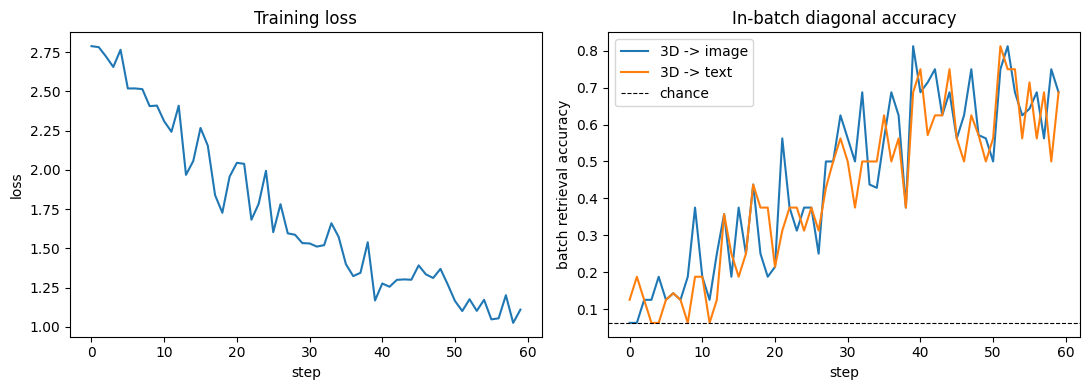

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["step"], history["loss"])
axes[0].set_xlabel("step"); axes[0].set_ylabel("loss"); axes[0].set_title("Training loss")

axes[1].plot(history["step"], history["acc_img"], label="3D -> image")
axes[1].plot(history["step"], history["acc_txt"], label="3D -> text")
axes[1].axhline(1 / BATCH_SIZE, color="black", linestyle="--", linewidth=0.8, label="chance")
axes[1].set_xlabel("step"); axes[1].set_ylabel("batch retrieval accuracy"); axes[1].set_title("In-batch diagonal accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


**What to observe.** The loss starts near $\ln 16 \approx 2.77$ (chance for a batch of 16) and
drops steadily. The accuracy curve is noisy because each point is measured on one batch of
only 16 objects - a single extra correct match moves it by ~6 points - so look at the trend,
not individual steps. Both curves rise together: the 3D encoder is being pulled toward image
*and* text at the same time.

## 11. Before vs. After Contrastive Learning

We now recompute the **exact same** similarity matrices and joint-embedding PCA plot
from Sections 7-8, using the identical objects and the identical subsampled points,
but with the **now-trained** 3D encoder. The claim we're testing is:

> Before alignment: $\cos\theta(a,+) \approx \cos\theta(a,-) \approx 0$ - a random encoder
> cannot tell its positive from a negative, so which one "wins" is a coin flip.
> After alignment: $\cos\theta(a,+) > \cos\theta(a,-)$, by a clear margin.

**What to look for:** in the AFTER matrices the diagonal should light up relative to
the off-diagonal. In the printed numbers, the *gap* between mean diagonal and mean
off-diagonal similarity is the thing that matters - absolute values stay modest because
CLIP embeddings of different objects are never orthogonal.

**Caveat, stated honestly:** these objects were also in the training set. What we see
here is that the loss did its job - the encoder *fit* the alignment - not yet evidence
that it generalizes to unseen objects (that needs a held-out split and a much larger
training run).


In [14]:
model.eval()
with torch.no_grad():
    z3d8_after = F.normalize(model(batch8["xyz"], batch8["features"]), dim=1).numpy()

sim_img8_after = z3d8_after @ zimg8.T
sim_txt8_after = z3d8_after @ ztxt8.T

fig_b1 = viz.plot_similarity_matrix(sim_img8, cats8, cats8, title="S: 3D<->Image -- BEFORE")
fig_a1 = viz.plot_similarity_matrix(sim_img8_after, cats8, cats8, title="S: 3D<->Image -- AFTER")
fig_b1.show(); fig_a1.show()

fig_b2 = viz.plot_similarity_matrix(sim_txt8, cats8, cats8, title="S: 3D<->Text -- BEFORE")
fig_a2 = viz.plot_similarity_matrix(sim_txt8_after, cats8, cats8, title="S: 3D<->Text -- AFTER")
fig_b2.show(); fig_a2.show()

diag_before = np.diag(sim_img8)
offdiag_before = sim_img8[~np.eye(len(sim_img8), dtype=bool)]
diag_after = np.diag(sim_img8_after)
offdiag_after = sim_img8_after[~np.eye(len(sim_img8_after), dtype=bool)]
print(f"3D<->Image  mean diagonal similarity:      before={diag_before.mean():.3f}  after={diag_after.mean():.3f}")
print(f"3D<->Image  mean off-diagonal similarity:   before={offdiag_before.mean():.3f}  after={offdiag_after.mean():.3f}")


3D<->Image  mean diagonal similarity:      before=-0.038  after=0.185
3D<->Image  mean off-diagonal similarity:   before=-0.038  after=-0.002


In [15]:
with torch.no_grad():
    z3d_joint_after = F.normalize(model(batch7["xyz"], batch7["features"]), dim=1).numpy()

all_emb_after = np.concatenate([z3d_joint_after, zimg_batch, ztxt_batch], axis=0)
coords7_after = pca7.transform(all_emb_after)  # reuse the SAME PCA basis fit before training

fig11 = viz.plot_joint_embedding_pca(coords7_after, modalities7, labels7, highlight=highlight,
                                       title="Joint embedding space (same PCA basis, AFTER training)")
fig11.show()


In [16]:
z_chair_3d_before = F.normalize(torch.from_numpy(z3d_batch[anchor_idx_in_subset:anchor_idx_in_subset + 1]), dim=1)
z_chair_3d_after = F.normalize(torch.from_numpy(z3d_joint_after[anchor_idx_in_subset:anchor_idx_in_subset + 1]), dim=1)
z_positive = torch.from_numpy(zimg_batch[anchor_idx_in_subset:anchor_idx_in_subset + 1])       # chair's own image
z_negative = torch.from_numpy(zimg_batch[negative_idx_in_subset:negative_idx_in_subset + 1])    # a different object's image

cos_pos_before = (z_chair_3d_before @ z_positive.T).item()
cos_neg_before = (z_chair_3d_before @ z_negative.T).item()
cos_pos_after = (z_chair_3d_after @ z_positive.T).item()
cos_neg_after = (z_chair_3d_after @ z_negative.T).item()

print("Anchor a = chair (3D embedding)")
print(f"  BEFORE:  cos(a, positive) = {cos_pos_before:+.3f}   cos(a, negative) = {cos_neg_before:+.3f}"
      f"   ->  {'positive ranks higher (correct)' if cos_pos_before > cos_neg_before else 'NEGATIVE ranks higher (wrong)'}")
print(f"  AFTER :  cos(a, positive) = {cos_pos_after:+.3f}   cos(a, negative) = {cos_neg_after:+.3f}"
      f"   ->  {'positive ranks higher (correct)' if cos_pos_after > cos_neg_after else 'NEGATIVE ranks higher (wrong)'}")


Anchor a = chair (3D embedding)
  BEFORE:  cos(a, positive) = -0.039   cos(a, negative) = -0.030   ->  NEGATIVE ranks higher (wrong)
  AFTER :  cos(a, positive) = +0.149   cos(a, negative) = -0.099   ->  positive ranks higher (correct)



## References

- Radford et al., *Learning Transferable Visual Models From Natural Language Supervision* (CLIP), ICML 2021 - arXiv:2103.00020
- Cherti et al., *Reproducible Scaling Laws for Contrastive Language-Image Learning* (OpenCLIP), CVPR 2023 - arXiv:2212.07143
- Yu et al., *Point-BERT: Pre-training 3D Point Cloud Transformers with Masked Point Modeling*, CVPR 2022 - arXiv:2111.14819
- Xue et al., *ULIP: Learning a Unified Representation of Language, Images, and Point Clouds*, CVPR 2023 - arXiv:2212.05171
- Liu et al., *OpenShape: Scaling Up 3D Shape Representation Towards Open-World Understanding*, NeurIPS 2023 - arXiv:2305.10764
- Zhou et al., *Uni3D: Exploring Unified 3D Representation at Scale*, ICLR 2024 - arXiv:2310.06773
- Liang et al., *Mind the Gap: Understanding the Modality Gap in Multi-modal Contrastive Representation Learning*, NeurIPS 2022 - arXiv:2203.02053
- Kusupati et al., *Matryoshka Representation Learning*, NeurIPS 2022 - arXiv:2205.13147